In [206]:
import pandas as pd
import numpy as np
import seaborn as sns

In [207]:
df_TCS = pd.read_csv("Data\IT_Data\TCS.NS_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\vishe\AppData\Local\Temp\ipykernel_31652\3603683878.py:1: SyntaxWarning: invalid escape sequence '\I'
  df_TCS = pd.read_csv("Data\IT_Data\TCS.NS_data.csv")


In [208]:
df_TCS.info()

<class 'pandas.DataFrame'>
RangeIndex: 2759 entries, 0 to 2758
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   2759 non-null   str  
 1   Close   2758 non-null   str  
 2   High    2758 non-null   str  
 3   Low     2758 non-null   str  
 4   Open    2758 non-null   str  
 5   Volume  2758 non-null   str  
dtypes: str(6)
memory usage: 129.5 KB


In [209]:
df_TCS.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-01,988.879638671875,997.2123838772336,987.1120636665565,997.2123838772336,366830
3,2015-01-02,1002.0490112304688,1006.516461209064,990.8415957982204,990.9969474257879,925740
4,2015-01-05,986.820556640625,1009.9929805494601,980.7603275085361,1002.6508637690987,1754242


In [210]:
df_TCS.describe()

,Price,Close,High,Low,Open,Volume
count,2759,2758,2758,2758,2758,2758
unique,2759,2742,2757,2758,2758,2757
top,Ticker,3380.860107421875,3160.0,TCS.NS,TCS.NS,0
freq,1,3,2,1,1,2


In [211]:
df_TCS = df_TCS.rename(columns={'Price':'Date'})

In [212]:
df_TCS = df_TCS.iloc[2:].reset_index(drop=True)

In [213]:
df_TCS['Date'] = pd.to_datetime(df_TCS['Date'])

decimal_values = ["Close", "High", "Low", "Open", "Volume"]
numeric_values =["Volume"]

for i in decimal_values:
    df_TCS[i] = df_TCS[i].astype(float)

for j in numeric_values:
    df_TCS[j] = pd.to_numeric(df_TCS[j])

In [214]:
df_TCS = df_TCS.sort_values(by="Date").reset_index(drop=True)

In [215]:
# Normalize Volume
df_TCS['Volume_Ratio'] = df_TCS['Volume'] / df_TCS['Volume'].rolling(window=20).mean()


### Visualize The Trends

In [216]:
import matplotlib.pyplot as plt

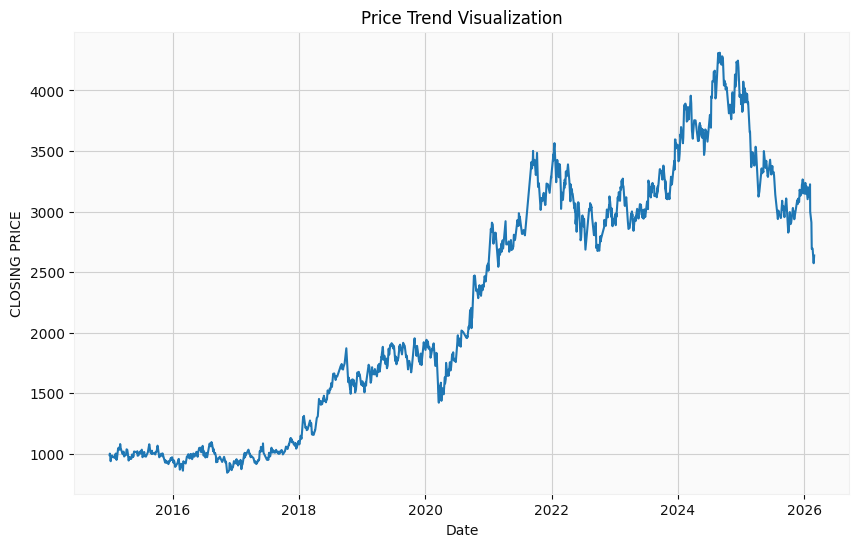

In [217]:
# Price Trend Over the Time
plt.figure(figsize=(10,6))
plt.plot(df_TCS['Date'], df_TCS['Close'], )
plt.title("Price Trend Visualization")
plt.xlabel("Date")
plt.ylabel("CLOSING PRICE")
plt.show()

<Figure size 1000x600 with 0 Axes>

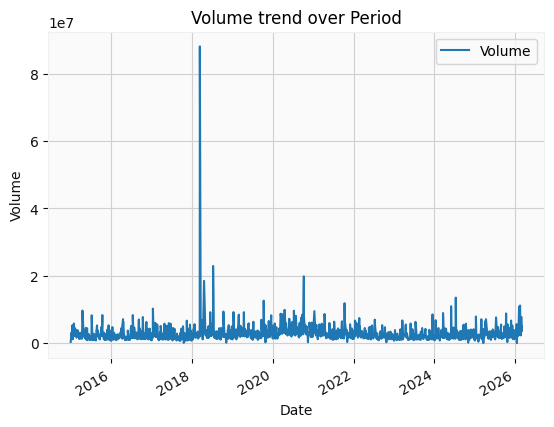

In [218]:
# Volume trend Over Time
plt.figure(figsize=(10,6))
df_TCS.plot(x='Date', y='Volume', kind='line', title="Volume trend over Period")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

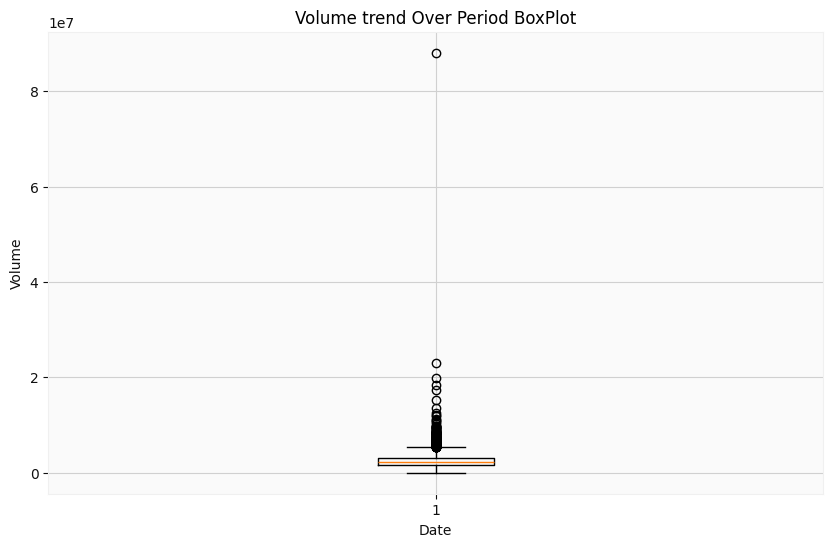

In [219]:
# The Line shows a Outlier in Volume . Check it using Box Plot
plt.figure(figsize=(10,6))
plt.boxplot(df_TCS["Volume"])
plt.title("Volume trend Over Period BoxPlot")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Daily Returns on Stocks

In [220]:
def daily_returns(close_price):
    returns=[None]
    for i in range(1, len(close_price)):
        daily_return = (close_price[i] - close_price[i-1])/close_price[i-1]
        returns.append(daily_return)
    return returns

df_TCS['Daily_Returns'] = daily_returns(df_TCS['Close'])

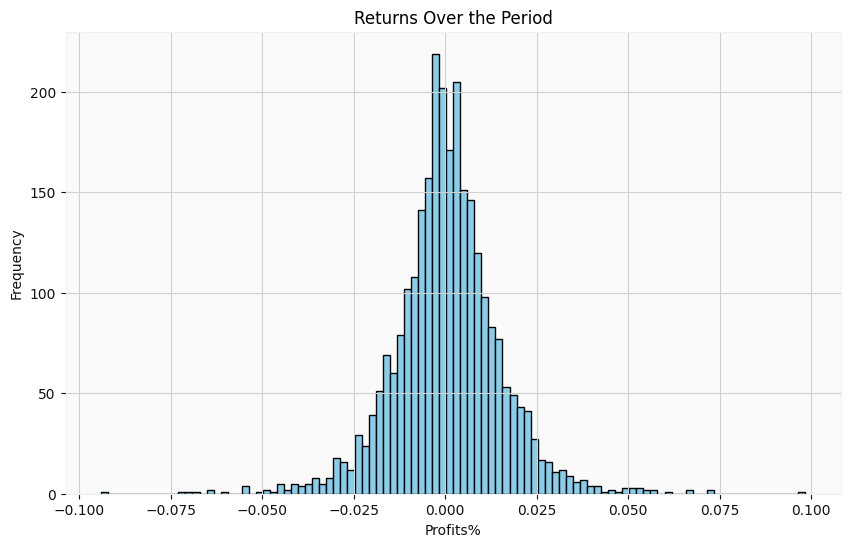

In [221]:
# Visualization of the Returns
plt.figure(figsize=(10,6))
plt.hist(df_TCS['Daily_Returns'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel("Profits%")
plt.ylabel("Frequency")
plt.title("Returns Over the Period")
plt.grid(True)
plt.show()

In [222]:
df_TCS

,Date,Close,High,Low,Open,Volume,Volume_Ratio,Daily_Returns
0,2015-01-01,988.879639,997.212384,987.112064,997.212384,366830.0,NaN,NaN
1,2015-01-02,1002.049011,1006.516461,990.841596,990.996947,925740.0,NaN,0.013317
2,2015-01-05,986.820557,1009.992981,980.760328,1002.650864,1754242.0,NaN,-0.015197
3,2015-01-06,950.440369,982.489468,947.876403,982.489468,2423784.0,NaN,-0.036866
4,2015-01-07,939.213501,963.085208,935.231643,959.530709,2636332.0,NaN,-0.011812
...,...,...,...,...,...,...,...,...
2752,2026-02-23,2676.300049,2704.000000,2660.199951,2686.000000,4699596.0,1.044845,-0.003685
2753,2026-02-24,2573.699951,2647.500000,2561.300049,2641.000000,7798833.0,1.668615,-0.038337
2754,2026-02-25,2629.300049,2654.199951,2595.000000,2596.000000,3621285.0,0.767654,0.021603
2755,2026-02-26,2647.699951,2671.000000,2635.000000,2650.000000,3464267.0,0.726616,0.006998


### Calculating Moving Averages Across the Range

In [223]:
df_TCS['MA_Week'] = df_TCS['Close'].rolling(window=7).mean()
df_TCS['MA_Week_Ratio'] = df_TCS['Close'] / df_TCS['MA_Week']

df_TCS['MA_Month'] = df_TCS['Close'].rolling(window=30).mean()
df_TCS['MA_Month_Ratio'] = df_TCS['Close'] / df_TCS['MA_Month']

df_TCS['MA_3Months'] = df_TCS['Close'].rolling(window=90).mean()
df_TCS['MA_3Months_Ratio'] = df_TCS['Close'] / df_TCS['MA_3Months']


In [224]:
df_TCS.head(10)

,Date,Close,High,Low,Open,Volume,Volume_Ratio,Daily_Returns,MA_Week,MA_Week_Ratio,MA_Month,MA_Month_Ratio,MA_3Months,MA_3Months_Ratio
0,2015-01-01,988.879639,997.212384,987.112064,997.212384,366830.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,1002.049011,1006.516461,990.841596,990.996947,925740.0,NaN,0.013317,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-05,986.820557,1009.992981,980.760328,1002.650864,1754242.0,NaN,-0.015197,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-06,950.440369,982.489468,947.876403,982.489468,2423784.0,NaN,-0.036866,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-07,939.213501,963.085208,935.231643,959.530709,2636332.0,NaN,-0.011812,NaN,NaN,NaN,NaN,NaN,NaN
5,2015-01-08,949.352600,951.372646,940.320581,948.808680,1565408.0,NaN,0.010795,NaN,NaN,NaN,NaN,NaN,NaN
6,2015-01-09,975.962891,978.915235,951.760950,953.703320,3197642.0,NaN,0.028030,970.388367,1.005745,NaN,NaN,NaN,NaN
7,2015-01-12,974.953003,982.062095,963.512465,977.788882,1596006.0,NaN,-0.001035,968.398847,1.006768,NaN,NaN,NaN,NaN
8,2015-01-13,970.368713,982.994112,963.453955,978.954023,1468432.0,NaN,-0.004702,963.873090,1.006739,NaN,NaN,NaN,NaN
9,2015-01-14,979.711914,983.538421,971.379166,977.400513,1787096.0,NaN,0.009629,962.857570,1.017505,NaN,NaN,NaN,NaN


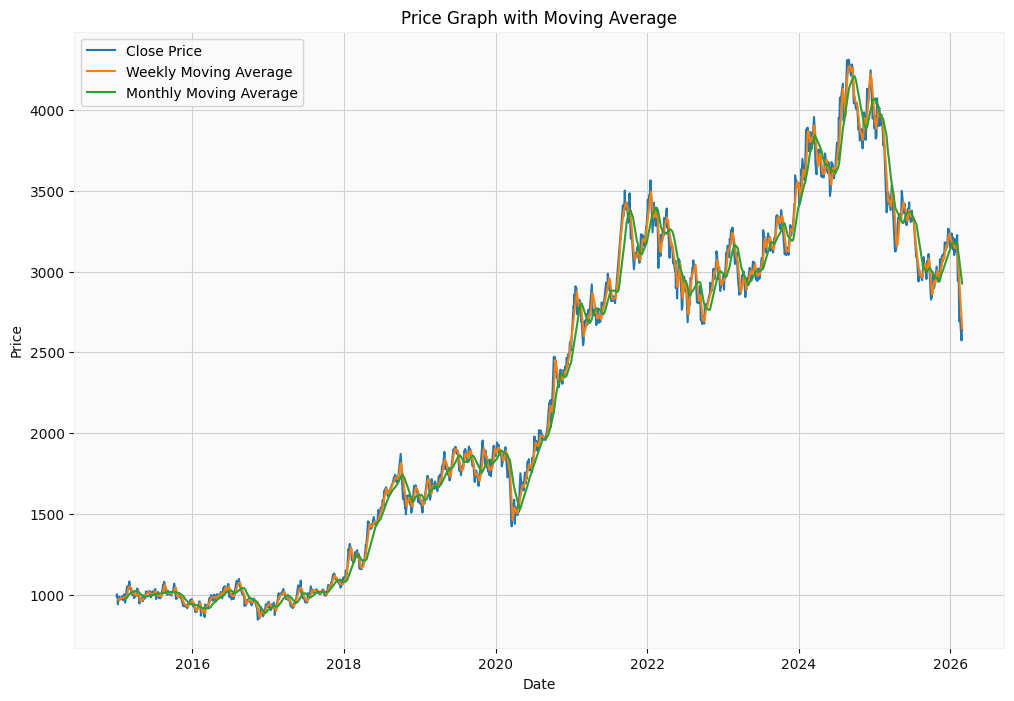

In [225]:
plt.figure(figsize=(12,8))
plt.plot(df_TCS['Date'], df_TCS['Close'], label='Close Price')
plt.plot(df_TCS['Date'], df_TCS['MA_Week'], label='Weekly Moving Average')
plt.plot(df_TCS['Date'], df_TCS['MA_Month'], label="Monthly Moving Average")
plt.title("Price Graph with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [226]:
df_TCS.isnull().sum()

Date                 0
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Volume_Ratio        19
Daily_Returns        1
MA_Week              6
MA_Week_Ratio        6
MA_Month            29
MA_Month_Ratio      29
MA_3Months          89
MA_3Months_Ratio    89
dtype: int64

c:\Users\vishe\OneDrive\Desktop\SUL_PROJECT\.venv\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


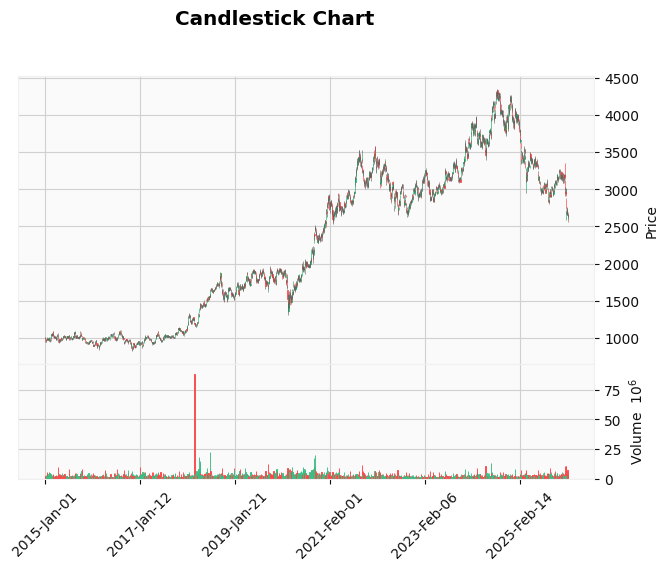

In [227]:
# CandleStick type of Chart
import mplfinance as mpf


# before that set the date column as index column
df_TCS = df_TCS.set_index('Date')
df_TCS = df_TCS.sort_index()

mpf.plot(df_TCS, type='candle', style='yahoo', title=f'Candlestick Chart', volume=True)


In [228]:
# Volatility to Measure the High Risk Periods
df_TCS['volatility'] = df_TCS['Daily_Returns'].rolling(window=3).std()

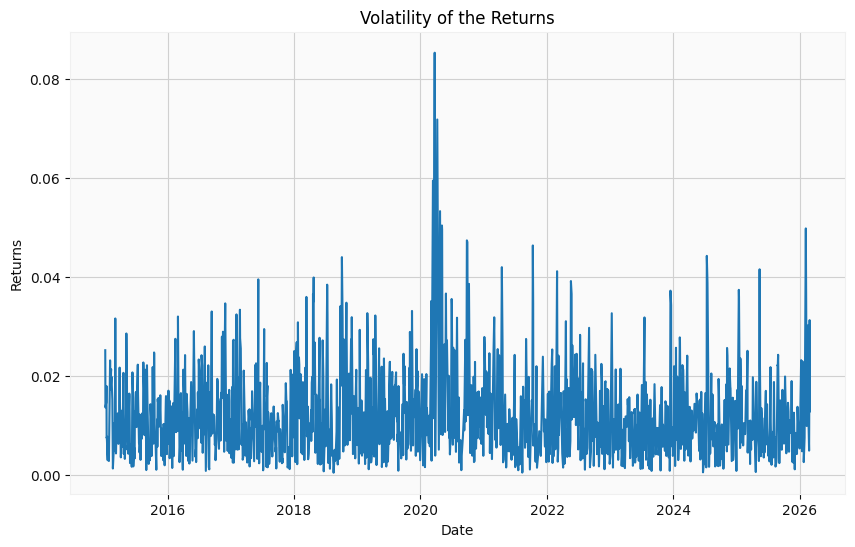

In [229]:
# Plot Date VS Volatily
plt.figure(figsize=(10,6))
plt.plot(df_TCS.index,df_TCS['volatility'])
plt.title("Volatility of the Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

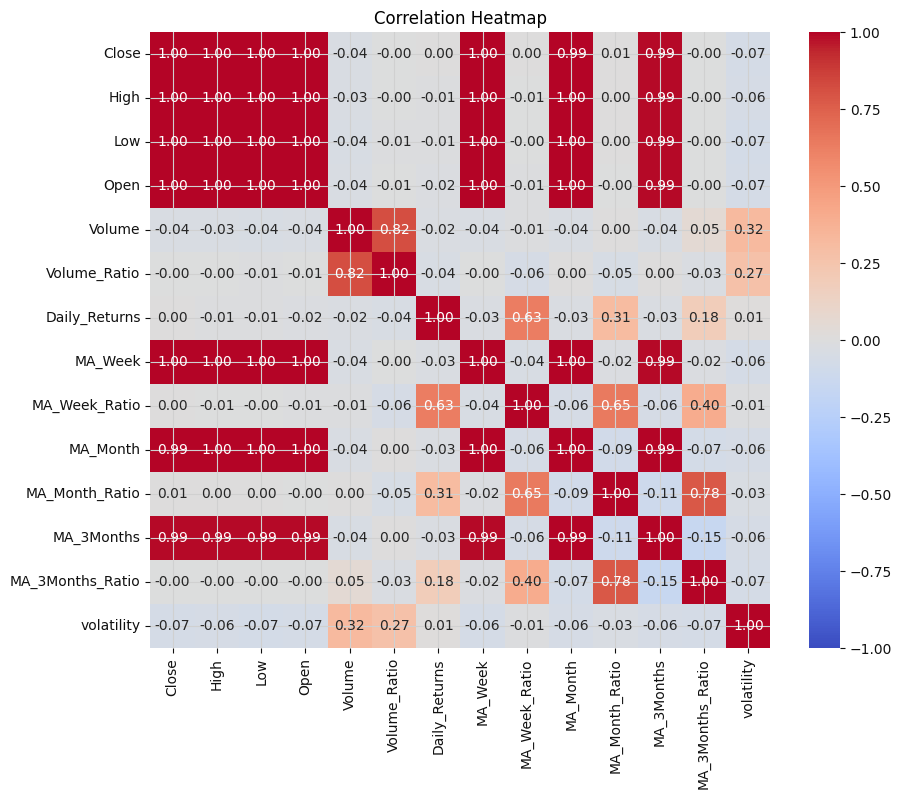

In [230]:
# Check the Correlation between all the calculated values
corr_matrix = df_TCS.select_dtypes('number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

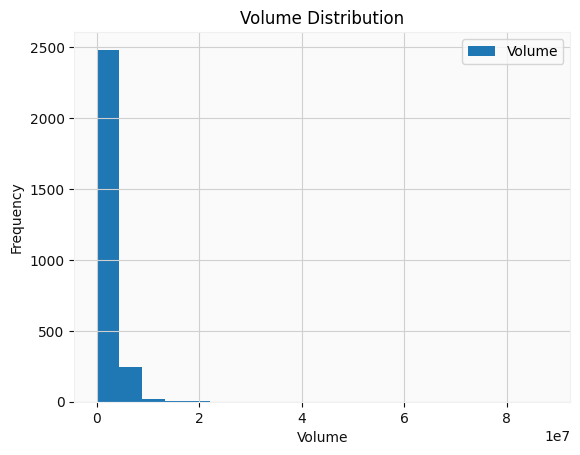

In [231]:
# Plot Histogram for Volume to check for trading activity 
df_TCS.plot(kind='hist', y='Volume', bins=20, title='Volume Distribution')
plt.xlabel("Volume")
plt.show()

In [232]:
# Computing RSI (Relative Strength Index) , it measures speed and magnitude of Price Movements

# RSI compares (Average Gains VS Average Losses)

delta = df_TCS['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain/avg_loss

df_TCS['RSI'] = 100-(100/(1+rs))

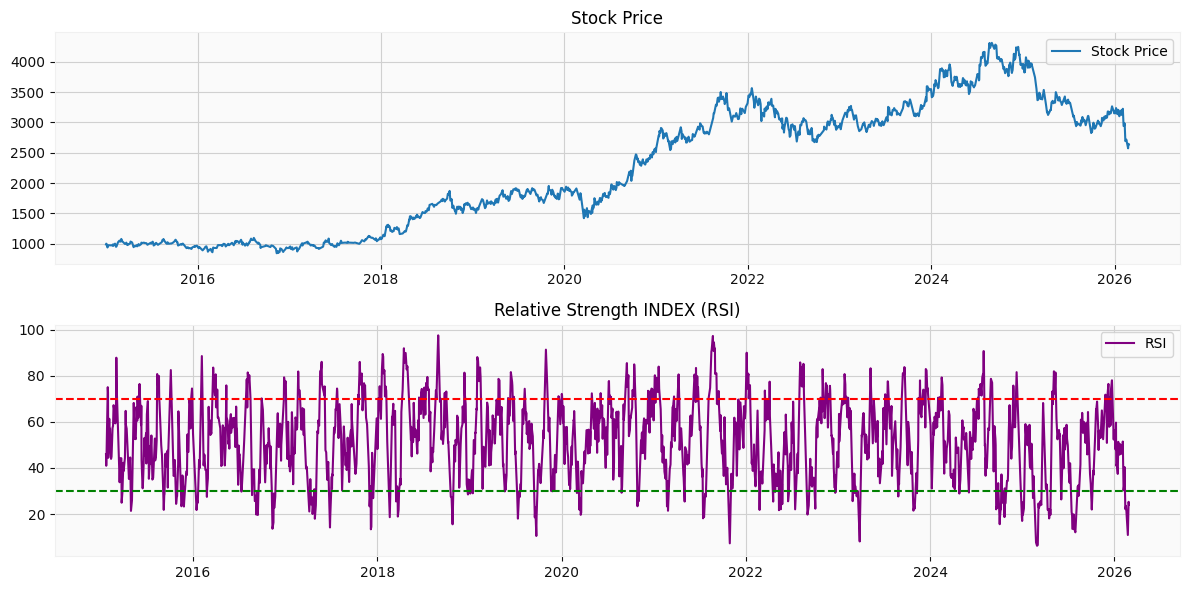

In [233]:
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(df_TCS['Close'], label= "Stock Price")
plt.title("Stock Price")
plt.legend()

plt.subplot(2,1,2)
plt.plot(df_TCS['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', color='red')  # threshold when stock is overbought
plt.axhline(30, linestyle='--', color='green') # threshold when stock is oversold

plt.title("Relative Strength INDEX (RSI)")

plt.legend()
plt.tight_layout()
plt.show()

### Creating Prediction Target

In [234]:
# if next day's return > 0 then target = 1 else 0


df_TCS['Next_Day_Return'] = df_TCS['Daily_Returns'].shift(-1)
df_TCS['Target'] = (df_TCS['Next_Day_Return'] > 0).astype(int)

In [235]:
df_TCS = df_TCS.dropna()

In [236]:
df_TCS.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2667 entries, 2015-05-15 to 2026-02-26
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Close             2667 non-null   float64
 1   High              2667 non-null   float64
 2   Low               2667 non-null   float64
 3   Open              2667 non-null   float64
 4   Volume            2667 non-null   float64
 5   Volume_Ratio      2667 non-null   float64
 6   Daily_Returns     2667 non-null   float64
 7   MA_Week           2667 non-null   float64
 8   MA_Week_Ratio     2667 non-null   float64
 9   MA_Month          2667 non-null   float64
 10  MA_Month_Ratio    2667 non-null   float64
 11  MA_3Months        2667 non-null   float64
 12  MA_3Months_Ratio  2667 non-null   float64
 13  volatility        2667 non-null   float64
 14  RSI               2667 non-null   float64
 15  Next_Day_Return   2667 non-null   float64
 16  Target            2667 non-null   i

### Time Based Train Test Split

In [237]:
df_TCS = df_TCS.sort_index()
split_index = int(len(df_TCS)*0.8)

train = df_TCS.iloc[0:split_index]
test = df_TCS.iloc[split_index: len(df_TCS)]


print(f"Training ENDS: {train.index.max()}")
print(f"Testing Starts: {test.index.min()}")

Training ENDS: 2024-01-01 00:00:00
Testing Starts: 2024-01-02 00:00:00


In [238]:
y_train = train['Target']
y_test = test['Target']



features=['Daily_Returns', 'Volume_Ratio', 'volatility', 'MA_Week_Ratio', 'MA_Month_Ratio', 'MA_3Months_Ratio', 'RSI']
X_train = train[features]
X_test = test[features]

### Fearture Scaling

In [239]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [240]:
X_trained_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

In [241]:
df_TCS.head(10)

,Close,High,Low,Open,Volume,Volume_Ratio,Daily_Returns,MA_Week,MA_Week_Ratio,MA_Month,MA_Month_Ratio,MA_3Months,MA_3Months_Ratio,volatility,RSI,Next_Day_Return,Target
Date,,,,,,,,,,,,,,,,,
2015-05-15,977.468506,985.740097,973.517643,978.967162,1461454.0,0.462025,0.004762,982.981855,0.994391,984.372323,0.992987,994.104308,0.983266,0.005726,52.584254,0.003683,1
2015-05-18,981.068909,982.956815,971.999430,978.616702,4507752.0,1.551668,0.003683,981.600028,0.999459,983.937016,0.997085,994.017522,0.986973,0.006168,52.866919,-0.003055,0
2015-05-19,978.071777,984.805844,971.863238,980.679742,1957722.0,0.684889,-0.003055,980.790946,0.997228,983.548413,0.994432,993.751108,0.984222,0.004236,52.494515,0.017650,1
2015-05-20,995.335144,1000.336967,979.706646,980.913363,1897814.0,0.671545,0.017650,980.849339,1.014769,983.674931,1.011854,993.845715,1.001499,0.010561,58.909234,-0.000607,0
2015-05-21,994.731445,1004.268100,991.870411,995.315322,1579578.0,0.585967,-0.000607,982.662118,1.012282,983.292167,1.011634,994.337838,1.000396,0.011314,62.425489,0.024418,1
2015-05-22,1019.020691,1023.244105,988.406122,992.590572,2691632.0,1.030049,0.024418,988.361808,1.031020,982.987250,1.036657,995.224584,1.023910,0.012944,66.469366,-0.006455,0
2015-05-25,1012.442505,1026.416587,1006.486942,1019.838279,982978.0,0.396202,-0.006455,994.019854,1.018533,982.162685,1.030830,995.925583,1.016584,0.016399,60.537365,0.003018,1
2015-05-26,1015.498230,1021.103410,1007.732591,1013.999575,1961740.0,0.803190,0.003018,999.452672,1.016054,981.580115,1.034555,996.364865,1.019203,0.015816,70.972365,0.002453,1
2015-05-27,1017.989502,1024.957062,1008.939409,1015.167430,1620690.0,0.684108,0.002453,1004.727042,1.013200,981.057878,1.037645,996.843048,1.021213,0.005314,62.877161,-0.002199,0


### Training Models

In [242]:
# Training A Logistic Regression Model
from sklearn.linear_model import LogisticRegression


model_Logistic_regression = LogisticRegression()

model_Logistic_regression.fit(X_trained_Scaled, y_train)


model_prediction_learning = model_Logistic_regression.predict(X_test_Scaled)

In [243]:
from sklearn.metrics import accuracy_score

prediction_Logistic_regression = accuracy_score(y_test, model_prediction_learning)
print(prediction_Logistic_regression)

0.46629213483146065


In [244]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model_prediction_learning)
print(cm)

[[ 47 241]
 [ 44 202]]


In [245]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, model_prediction_learning)
print(cr)

              precision    recall  f1-score   support

           0       0.52      0.16      0.25       288
           1       0.46      0.82      0.59       246

    accuracy                           0.47       534
   macro avg       0.49      0.49      0.42       534
weighted avg       0.49      0.47      0.40       534



In [246]:
'''
Despite a balanced dataset, the model exhibited biased 
predictions due to the weak and noisy nature of stock market signals. 
This suggests that simple linear models are insufficient for capturing 
market dynamics.
'''

'\nDespite a balanced dataset, the model exhibited biased \npredictions due to the weak and noisy nature of stock market signals. \nThis suggests that simple linear models are insufficient for capturing \nmarket dynamics.\n'

### Using the Decision Trees Algorithm 

In [247]:
from sklearn.tree import DecisionTreeClassifier

Decision_Tree_Model = DecisionTreeClassifier(random_state=42, max_depth=14)

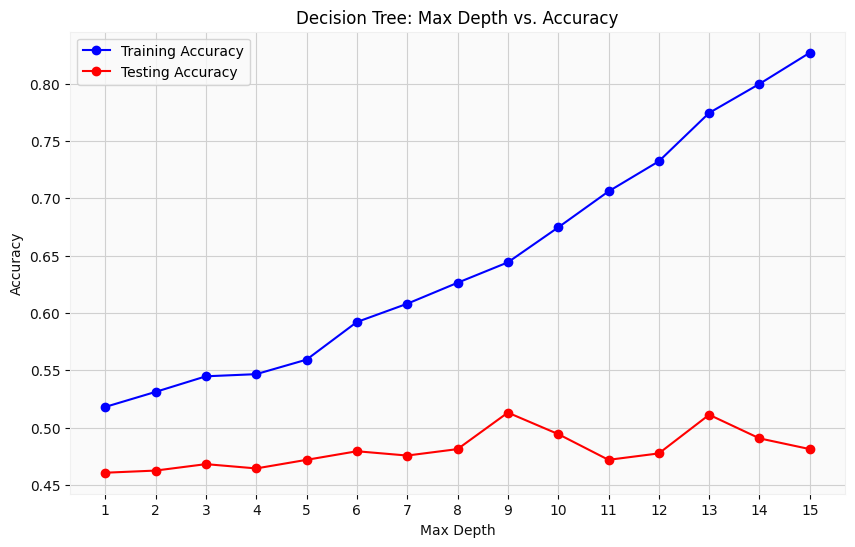

In [248]:
train_accuracies = []
test_accuracies = []

# The range of depths we want to test (from 1 to 15)
depth_range = range(1, 16)

# Loop through each depth
for depth in depth_range:
    # 1. Build and train the tree
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_trained_Scaled, y_train)
    
    # 2. Check accuracy on Training Data
    train_pred = tree.predict(X_trained_Scaled)
    train_acc = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_acc)
    
    # 3. Check accuracy on Testing Data
    test_pred = tree.predict(X_test_Scaled)
    test_acc = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_acc)

# --- Plotting the Results ---
plt.figure(figsize=(10, 6))
plt.plot(depth_range, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(depth_range, test_accuracies, label='Testing Accuracy', marker='o', color='red')

plt.title('Decision Tree: Max Depth vs. Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(depth_range)
plt.legend()
plt.grid(True)
plt.show()

In [249]:
Decision_Tree_Model.fit(X_trained_Scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [250]:
Decision_Tree_Predictions = Decision_Tree_Model.predict(X_test_Scaled)

In [251]:
Decision_Tree_Accuracy = accuracy_score(y_test, Decision_Tree_Predictions)
print(Decision_Tree_Accuracy)

0.49063670411985016


In [252]:
DT_cm = confusion_matrix(y_test, Decision_Tree_Predictions)
print(DT_cm)

[[ 98 190]
 [ 82 164]]


In [253]:
DT_cr = classification_report(y_test, Decision_Tree_Predictions)
print(DT_cr)

              precision    recall  f1-score   support

           0       0.54      0.34      0.42       288
           1       0.46      0.67      0.55       246

    accuracy                           0.49       534
   macro avg       0.50      0.50      0.48       534
weighted avg       0.51      0.49      0.48       534



In [254]:
# The previous model predicted model would go up 441 times, catching almost all the upward trends but failing miserably at identifying downward trends . 

In [255]:
# The Decision Tree Completely Fixed this blind spot . BY chaining those IF/THEN rules togeather, It successfully identified 163 True Down days (True Negatives). That is an improvement of 240% in protecting capital from bad trades.

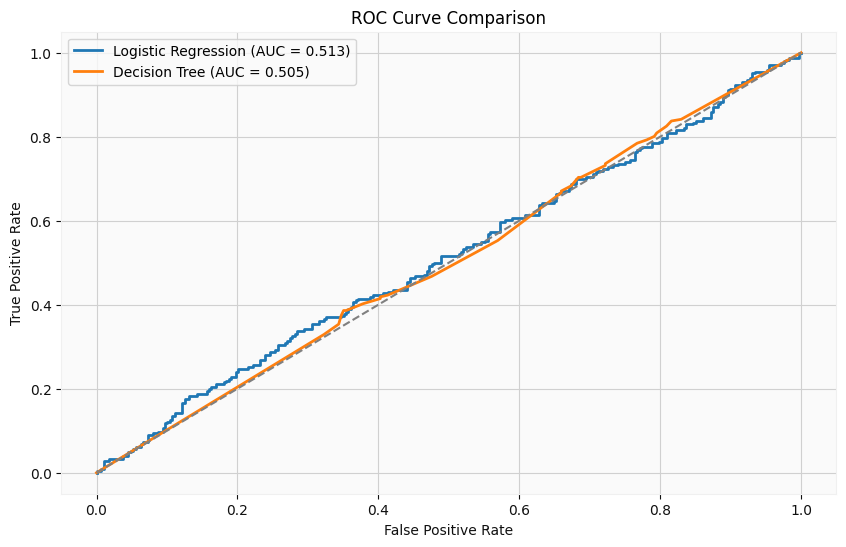

Logistic Regression AUC: 0.5133
Decision Tree AUC: 0.5046


In [256]:
from sklearn.metrics import roc_curve, roc_auc_score

logistic_probs = model_Logistic_regression.predict_proba(X_test_Scaled)[:, 1]
decision_tree_probs = Decision_Tree_Model.predict_proba(X_test_Scaled)[:, 1]

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_probs)
decision_tree_fpr, decision_tree_tpr, _ = roc_curve(y_test, decision_tree_probs)

logistic_auc = roc_auc_score(y_test, logistic_probs)
decision_tree_auc = roc_auc_score(y_test, decision_tree_probs)

plt.figure(figsize=(10, 6))
plt.plot(logistic_fpr, logistic_tpr, label=f'Logistic Regression (AUC = {logistic_auc:.3f})', linewidth=2)
plt.plot(decision_tree_fpr, decision_tree_tpr, label=f'Decision Tree (AUC = {decision_tree_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

print(f"Logistic Regression AUC: {logistic_auc:.4f}")
print(f"Decision Tree AUC: {decision_tree_auc:.4f}")
